<a href="https://colab.research.google.com/github/eevvvaa/Deep_Generative_Model-HW/blob/%E4%BD%9C%E6%A5%AD4-%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97/%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Cell 0 — 安裝套件（Colab 執行）
!pip install yfinance ta seaborn --quiet

In [7]:
# Cell 1 — imports & 設定
import math, os, random, datetime
from typing import Tuple, List, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta   # technical analysis indicators helper
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [13]:
# Cell 2 — 下載資料 (yfinance)，並展示 head
ticker = "2330.TW"    # 可改成 "AAPL" / "TSLA" / "MSFT"
start = "2020-01-01"
end = "2024-12-31"

df = yf.download(ticker, start=start, end=end, progress=False)

# 若欄位是多層 MultiIndex，扁平化
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# yfinance 讀到的 columns: Open, High, Low, Close, Adj Close, Volume
df = df.rename(columns={"Adj Close": "Adj_Close"})
df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

print("columns:", df.columns)
print("rows:", len(df))
print(df.head())

/tmp/ipython-input-2575006068.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


columns: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
rows: 1214
Price             Open        High         Low       Close    Volume
Date                                                                
2020-01-02  295.573735  301.351868  295.573735  301.351868  31754120
2020-01-03  305.796695  306.685639  298.240672  301.796448  41811268
2020-01-06  296.018247  297.351662  295.129303  295.129303  45343057
2020-01-07  295.573783  296.018255  290.240121  292.906952  50879181
2020-01-08  288.906705  296.018255  288.906705  292.906952  37567748


In [14]:
# Cell 3 — 加技術指標 (最終能執行版)
import numpy as np
import pandas as pd
from ta.momentum import RSIIndicator
from ta.trend import MACD

df_t = df.copy()

# === 強制把 Close 攤平成一維 ===
if isinstance(df_t["Close"], pd.DataFrame):
    # 如果 Close 是 DataFrame（shape 為 (n,1)）
    df_t["Close"] = df_t["Close"].squeeze()  # 轉成 Series

# 若 squeeze 後仍有多層索引（例如 MultiIndex），只取值
if isinstance(df_t["Close"].iloc[0], (np.ndarray, list)):
    df_t["Close"] = df_t["Close"].apply(lambda x: float(x[0]))

# 確保型態為 float
df_t["Close"] = df_t["Close"].astype(float)

# 確認形狀
print("確認 Close 欄位型別：", type(df_t["Close"]))
print("確認 Close 形狀：", np.array(df_t["Close"]).shape)
print("前 5 筆值：")
print(df_t["Close"].head())

# === 計算技術指標 ===
df_t["SMA_5"] = df_t["Close"].rolling(window=5).mean()
df_t["SMA_20"] = df_t["Close"].rolling(window=20).mean()

# RSI (14)
df_t["RSI_14"] = RSIIndicator(close=df_t["Close"], window=14).rsi()

# MACD (12, 26, 9)
macd = MACD(close=df_t["Close"], window_slow=26, window_fast=12, window_sign=9)
df_t["MACD"] = macd.macd()
df_t["MACD_SIGNAL"] = macd.macd_signal()
df_t["MACD_HIST"] = df_t["MACD"] - df_t["MACD_SIGNAL"]

# 清除 NA
df_t = df_t.dropna().copy()

print("After indicators rows:", len(df_t))
display(df_t.tail())

確認 Close 欄位型別： <class 'pandas.core.series.Series'>
確認 Close 形狀： (1214,)
前 5 筆值：
Date
2020-01-02    301.351868
2020-01-03    301.796448
2020-01-06    295.129303
2020-01-07    292.906952
2020-01-08    292.906952
Name: Close, dtype: float64
After indicators rows: 1181


Price,Open,High,Low,Close,Volume,SMA_5,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST
Date,,,,,,,,,,,
2024-12-24,1080.990833,1080.990833,1066.182739,1066.182739,26461906,1056.310645,1040.369150,56.218900,10.555905,9.627550,0.928355
2024-12-25,1076.054683,1076.054683,1066.182622,1071.118652,15481622,1056.310645,1044.753696,57.243757,11.316937,9.965428,1.351509
2024-12-26,1071.118652,1076.054683,1071.118652,1071.118652,14374900,1059.272241,1048.892386,57.243757,11.784218,10.329186,1.455033
2024-12-27,1066.182626,1080.990718,1066.182626,1076.054688,24948385,1070.131494,1053.720419,58.373873,12.409787,10.745306,1.664481
2024-12-30,1076.054688,1080.990718,1071.118657,1076.054688,23954634,1072.105884,1056.630768,58.373873,12.758483,11.147941,1.610541


In [15]:
# Cell 4 — 建立特徵與目標 (log return) 與 time-based split (8/1/1)
# features: Open,High,Low,Close,Volume,SMA_5,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST (可調)
features = ["Open","High","Low","Close","Volume","SMA_5","SMA_20","RSI_14","MACD","MACD_SIGNAL","MACD_HIST"]
df_t = df_t[features].copy()
# target = logret[t] = log(Close[t+1]) - log(Close[t]) -> we'll shift -1 to make sample at t predict t+1
df_t["logret"] = np.log(df_t["Close"].shift(-1)) - np.log(df_t["Close"])
# drop last row because target is NaN
df_t = df_t.dropna().copy()
dates = df_t.index
n = len(df_t)
train_end = int(n * 0.8)
val_end = int(n * 0.9)
print("total rows:", n, "train_end:", train_end, "val_end:", val_end)
train_df = df_t.iloc[:train_end].copy()
val_df = df_t.iloc[train_end:val_end].copy()
test_df = df_t.iloc[val_end:].copy()
print("train/val/test sizes:", len(train_df), len(val_df), len(test_df))

total rows: 1180 train_end: 944 val_end: 1062
train/val/test sizes: 944 118 118


In [16]:
# Cell 5 — 標準化 (只用 train fit)，並建立 sliding-window dataset
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()  # apply to target for standardized-space metrics

X_train = train_df[features].values
X_val = val_df[features].values
X_test = test_df[features].values
y_train = train_df["logret"].values.reshape(-1,1)
y_val = val_df["logret"].values.reshape(-1,1)
y_test = test_df["logret"].values.reshape(-1,1)

scaler_X.fit(X_train)
scaler_y.fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_val_s = scaler_X.transform(X_val)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train).squeeze()
y_val_s = scaler_y.transform(y_val).squeeze()
y_test_s = scaler_y.transform(y_test).squeeze()

# dataset generator with lookback
LOOKBACK = 30  # 30 days
BATCH_SIZE = 64
def make_windows(X, y, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(len(X)-lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])  # predict t+1 (already aligned)
    return np.array(Xs), np.array(ys)

Xtr, ytr = make_windows(X_train_s, y_train_s)
Xv, yv = make_windows(X_val_s, y_val_s)
Xt, yt = make_windows(X_test_s, y_test_s)

print("shapes Xtr, ytr:", Xtr.shape, ytr.shape)

shapes Xtr, ytr: (914, 30, 11) (914,)


In [17]:
# Cell 6 — PyTorch Dataset & DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N,1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(Xtr,ytr), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(TimeSeriesDataset(Xv,yv), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(Xt,yt), batch_size=BATCH_SIZE, shuffle=False)

In [18]:
# Cell 7 — LSTM baseline model (1 layer LSTM -> LayerNorm -> Linear -> 1)
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden, num_layers=1, batch_first=True, dropout=dropout)
        self.ln = nn.LayerNorm(hidden)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        # x: (B, T, F)
        out, (h, c) = self.lstm(x)  # out: (B, T, hidden)
        last = out[:, -1, :]        # take last time step
        last = self.ln(last)
        return self.fc(last)

input_dim = len(features)
lstm_model = LSTMModel(input_dim).to(DEVICE)
print(lstm_model)

LSTMModel(
  (lstm): LSTM(11, 128, batch_first=True, dropout=0.1)
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


In [19]:
# Cell 8 — Transformer Encoder-only model with sinusoidal pos enc, 2 layers, mean pooling, and returning attention maps
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer('pe', pe)
    def forward(self, x):
        # x shape (B, T, d_model)
        return x + self.pe[:, :x.size(1), :]

class TransformerEncoderModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "mha": nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True),
                "ln1": nn.LayerNorm(d_model),
                "ff": nn.Sequential(nn.Linear(d_model, dim_feedforward), nn.ReLU(), nn.Dropout(dropout), nn.Linear(dim_feedforward, d_model)),
                "ln2": nn.LayerNorm(d_model)
            }) for _ in range(num_layers)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)  # mean pooling across time via permute
        self.head = nn.Linear(d_model, 1)
    def forward(self, x, return_attn=False):
        # x: (B, T, F)
        x = self.input_proj(x)           # (B, T, d_model)
        x = self.pos_enc(x)
        attn_maps = []
        for layer in self.layers:
            # MultiheadAttention expects (B, T, E) with batch_first=True (PyTorch >=1.11)
            attn_out, attn_weights = layer["mha"](x, x, x, need_weights=True, average_attn_weights=False)
            x = layer["ln1"](x + attn_out)
            ff = layer["ff"](x)
            x = layer["ln2"](x + ff)
            # attn_weights shape: (B, num_heads, T, T) if average_attn_weights=False in newer torch
            attn_maps.append(attn_weights.detach().cpu())
        # mean pooling over time
        # x: (B, T, d_model) -> permute to (B, d_model, T) for AdaptiveAvgPool1d
        x_pooled = x.permute(0,2,1)
        x_mean = self.pool(x_pooled).squeeze(-1)  # (B, d_model)
        out = self.head(x_mean)
        if return_attn:
            return out, attn_maps
        else:
            return out

transformer_model = TransformerEncoderModel(input_dim=input_dim, d_model=128, nhead=8, num_layers=2).to(DEVICE)
print(transformer_model)

TransformerEncoderModel(
  (input_proj): Linear(in_features=11, out_features=128, bias=True)
  (pos_enc): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (head): Linear(in_features=128, out_features=1, bias=True)
)


In [20]:
# Cell 9 — 訓練與驗證公用 function (返回歷史 loss/metrics)
def evaluate(model, loader, criterion, scaler_y):
    model.eval()
    ys_true_s = []
    ys_pred_s = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            if isinstance(model, TransformerEncoderModel):
                y_pred = model(xb)
            else:
                y_pred = model(xb)
            ys_true_s.append(yb.cpu().numpy())
            ys_pred_s.append(y_pred.cpu().numpy())
    ys_true_s = np.vstack(ys_true_s).squeeze()
    ys_pred_s = np.vstack(ys_pred_s).squeeze()
    # standardized-space metrics
    mse_s = mean_squared_error(ys_true_s, ys_pred_s)
    mae_s = mean_absolute_error(ys_true_s, ys_pred_s)
    rmse_s = np.sqrt(mse_s)
    # convert back to original logret space
    ys_true = scaler_y.inverse_transform(ys_true_s.reshape(-1,1)).squeeze()
    ys_pred = scaler_y.inverse_transform(ys_pred_s.reshape(-1,1)).squeeze()
    mse_o = mean_squared_error(ys_true, ys_pred)
    mae_o = mean_absolute_error(ys_true, ys_pred)
    rmse_o = np.sqrt(mse_o)
    return {"mse_s":mse_s,"mae_s":mae_s,"rmse_s":rmse_s, "mse_o":mse_o,"mae_o":mae_o,"rmse_o":rmse_o, "y_true":ys_true, "y_pred":ys_pred}

In [21]:
# Cell 10 — LSTM 訓練 loop (epochs=30, Adam lr=1e-4)
def train_model(model, train_loader, val_loader, epochs, optimizer, scheduler=None, scaler_y=None, model_name="model"):
    criterion = nn.MSELoss()
    history = {"epoch":[], "val_rmse_s":[]}
    best_val_rmse = float('inf')
    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            # if scheduler is CosineAnnealingWarmRestarts, step needs epoch + batch info; simple step per epoch:
            scheduler.step()
        # validate
        stats = evaluate(model, val_loader, criterion, scaler_y)
        history["epoch"].append(ep)
        history["val_rmse_s"].append(stats["rmse_s"])
        print(f"{model_name} Epoch {ep}/{epochs} - val_rmse_s: {stats['rmse_s']:.6f} rmse_o: {stats['rmse_o']:.6f}")
        # save best
        if stats["rmse_s"] < best_val_rmse:
            best_val_rmse = stats["rmse_s"]
            torch.save(model.state_dict(), f"{model_name}_best.pth")
    return history
# train LSTM
lstm_opt = Adam(lstm_model.parameters(), lr=1e-4)
epochs = 30
history_lstm = train_model(lstm_model, train_loader, val_loader, epochs, lstm_opt, scheduler=None, scaler_y=scaler_y, model_name="lstm")

lstm Epoch 1/30 - val_rmse_s: 1.322835 rmse_o: 0.022847
lstm Epoch 2/30 - val_rmse_s: 1.300855 rmse_o: 0.022467
lstm Epoch 3/30 - val_rmse_s: 1.231080 rmse_o: 0.021262
lstm Epoch 4/30 - val_rmse_s: 1.213249 rmse_o: 0.020954
lstm Epoch 5/30 - val_rmse_s: 1.222451 rmse_o: 0.021113
lstm Epoch 6/30 - val_rmse_s: 1.224418 rmse_o: 0.021147
lstm Epoch 7/30 - val_rmse_s: 1.221536 rmse_o: 0.021097
lstm Epoch 8/30 - val_rmse_s: 1.220042 rmse_o: 0.021071
lstm Epoch 9/30 - val_rmse_s: 1.218561 rmse_o: 0.021046
lstm Epoch 10/30 - val_rmse_s: 1.217605 rmse_o: 0.021029
lstm Epoch 11/30 - val_rmse_s: 1.217594 rmse_o: 0.021029
lstm Epoch 12/30 - val_rmse_s: 1.218020 rmse_o: 0.021037
lstm Epoch 13/30 - val_rmse_s: 1.218835 rmse_o: 0.021051
lstm Epoch 14/30 - val_rmse_s: 1.220032 rmse_o: 0.021071
lstm Epoch 15/30 - val_rmse_s: 1.221509 rmse_o: 0.021097
lstm Epoch 16/30 - val_rmse_s: 1.223208 rmse_o: 0.021126
lstm Epoch 17/30 - val_rmse_s: 1.225072 rmse_o: 0.021158
lstm Epoch 18/30 - val_rmse_s: 1.227057 

In [22]:
# Cell 11 — Transformer 訓練 (AdamW lr=3e-4, weight_decay=1e-4, warmup 10% epochs + CosineAnnealingWarmRestarts)
def get_warmup_scheduler(optimizer, warmup_steps, total_steps):
    # simple linear warmup then return None (we will implement simple warmup manually in training loop)
    return None

transformer_opt = AdamW(transformer_model.parameters(), lr=3e-4, weight_decay=1e-4)
# Use CosineAnnealingWarmRestarts as requested — step per epoch
transformer_sched = CosineAnnealingWarmRestarts(transformer_opt, T_0=5, T_mult=1)
# We'll do a simple warmup manually: scale lr by factor = min(1, step/warmup_steps)
warmup_epochs = max(1, int(epochs * 0.1))

def train_transformer(model, train_loader, val_loader, epochs, optimizer, scheduler, scaler_y, warmup_epochs=warmup_epochs, model_name="transformer"):
    criterion = nn.MSELoss()
    best_val = float('inf')
    history = {"epoch":[],"val_rmse_s":[]}
    global_step = 0
    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in train_loader:
            global_step += 1
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            # warmup lr scaling
            if ep <= warmup_epochs:
                for g in optimizer.param_groups:
                    g['lr'] = 3e-4 * (ep / warmup_epochs)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
        stats = evaluate(model, val_loader, criterion, scaler_y)
        history["epoch"].append(ep); history["val_rmse_s"].append(stats["rmse_s"])
        print(f"{model_name} Epoch {ep}/{epochs} - val_rmse_s: {stats['rmse_s']:.6f} rmse_o: {stats['rmse_o']:.6f}")
        if stats["rmse_s"] < best_val:
            best_val = stats["rmse_s"]
            torch.save(model.state_dict(), f"{model_name}_best.pth")
    return history

history_trans = train_transformer(transformer_model, train_loader, val_loader, epochs, transformer_opt, transformer_sched, scaler_y, warmup_epochs, model_name="transformer")

transformer Epoch 1/30 - val_rmse_s: 1.268065 rmse_o: 0.021901
transformer Epoch 2/30 - val_rmse_s: 1.143905 rmse_o: 0.019756
transformer Epoch 3/30 - val_rmse_s: 1.391679 rmse_o: 0.024036
transformer Epoch 4/30 - val_rmse_s: 1.164732 rmse_o: 0.020116
transformer Epoch 5/30 - val_rmse_s: 1.139021 rmse_o: 0.019672
transformer Epoch 6/30 - val_rmse_s: 1.199711 rmse_o: 0.020720
transformer Epoch 7/30 - val_rmse_s: 1.157374 rmse_o: 0.019989
transformer Epoch 8/30 - val_rmse_s: 1.264159 rmse_o: 0.021833
transformer Epoch 9/30 - val_rmse_s: 1.170787 rmse_o: 0.020221
transformer Epoch 10/30 - val_rmse_s: 1.178862 rmse_o: 0.020360
transformer Epoch 11/30 - val_rmse_s: 1.209413 rmse_o: 0.020888
transformer Epoch 12/30 - val_rmse_s: 1.232509 rmse_o: 0.021287
transformer Epoch 13/30 - val_rmse_s: 1.235014 rmse_o: 0.021330
transformer Epoch 14/30 - val_rmse_s: 1.214019 rmse_o: 0.020967
transformer Epoch 15/30 - val_rmse_s: 1.221172 rmse_o: 0.021091
transformer Epoch 16/30 - val_rmse_s: 1.252093 rm

In [23]:
# Cell 12 — 載入最佳模型 & 在測試集上做評估，並計算兩種尺度指標 (標準化 & 原始)
# load best
lstm_model.load_state_dict(torch.load("lstm_best.pth"))
transformer_model.load_state_dict(torch.load("transformer_best.pth"))

lstm_stats = evaluate(lstm_model, test_loader, nn.MSELoss(), scaler_y)
transformer_stats = evaluate(transformer_model, test_loader, nn.MSELoss(), scaler_y)

print("LSTM test metrics (std-space):", {"MSE":lstm_stats["mse_s"],"MAE":lstm_stats["mae_s"],"RMSE":lstm_stats["rmse_s"]})
print("LSTM test metrics (orig logret):", {"MSE":lstm_stats["mse_o"],"MAE":lstm_stats["mae_o"],"RMSE":lstm_stats["rmse_o"]})
print("Transformer test metrics (std-space):", {"MSE":transformer_stats["mse_s"],"MAE":transformer_stats["mae_s"],"RMSE":transformer_stats["rmse_s"]})
print("Transformer test metrics (orig logret):", {"MSE":transformer_stats["mse_o"],"MAE":transformer_stats["mae_o"],"RMSE":transformer_stats["rmse_o"]})

LSTM test metrics (std-space): {'MSE': 1.2134242057800293, 'MAE': 0.839908242225647, 'RMSE': np.float64(1.101555357564943)}
LSTM test metrics (orig logret): {'MSE': 0.0003619532799348235, 'MAE': 0.014506139792501926, 'RMSE': np.float64(0.019025069774768855)}
Transformer test metrics (std-space): {'MSE': 1.1171268224716187, 'MAE': 0.805349588394165, 'RMSE': np.float64(1.0569422039409813)}
Transformer test metrics (orig logret): {'MSE': 0.0003332287014927715, 'MAE': 0.01390927191823721, 'RMSE': np.float64(0.018254552897640948)}


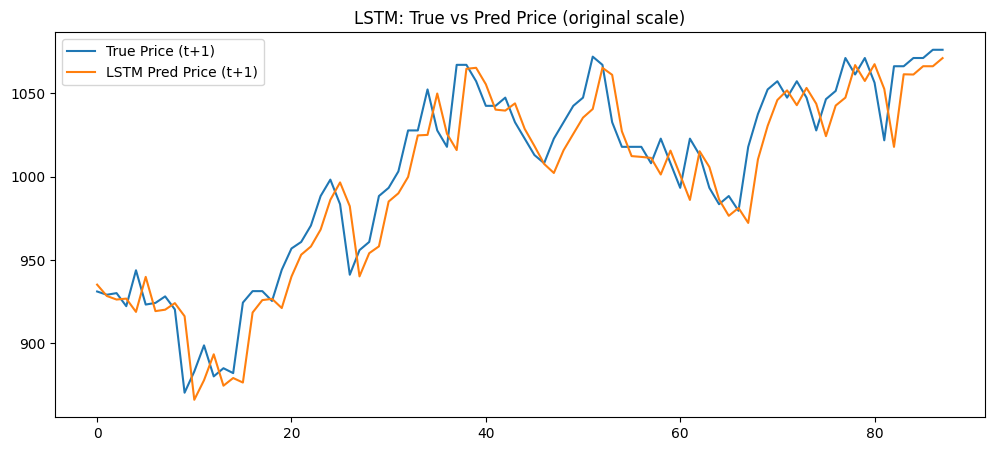

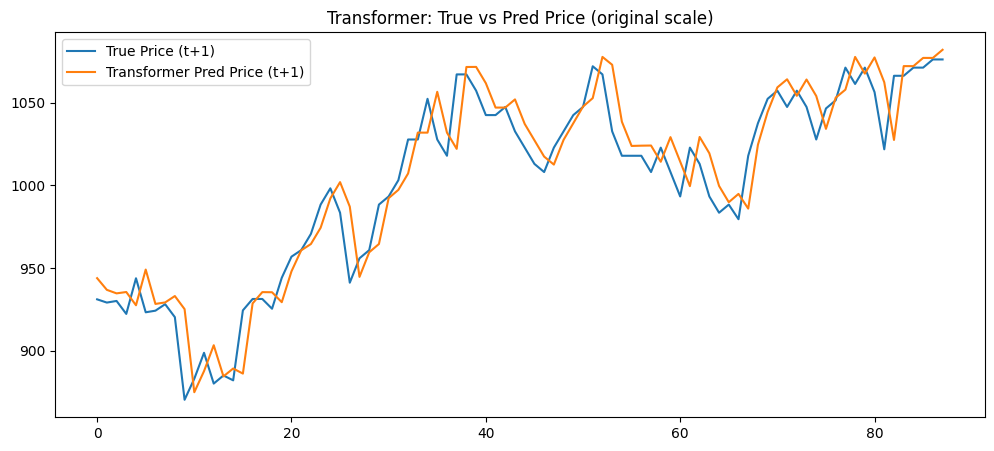

In [24]:
# Cell 13 — 畫出 True vs Pred（回到原始價格尺度）
# 我們要把 logret 預測結果轉回 price： price_pred[t+1] = price[t] * exp(pred_logret)
# 因為我們做的是以 t 的 window 預測 t+1，我們需要搭配對應的 t price 序列來回算
def reconstruct_price_series(df_original_close, X_windows, y_pred_logret_orig):
    # df_original_close: array aligned with df_t['Close'] used earlier (not shifted)
    # X_windows length = N_samples, each window ends at index (i + lookback - 1). Pred at index i+lookback corresponds to original close at that index.
    # We will compute predicted price for t+1 by price_t * exp(pred_logret)
    closes = df_original_close[LOOKBACK:LOOKBACK + len(y_pred_logret_orig)]  # price at time t for each sample
    price_pred = closes * np.exp(y_pred_logret_orig)
    return closes, price_pred

# get arrays for test set to reconstruct
# We need the original Close values aligned. We have X_test_s panels — get original closes from test_df
test_closes = test_df["Close"].values  # aligned to rows used earlier; recall we made windows earlier so skip first LOOKBACK entries when reconstructing
# For LSTM
lstm_y_true_orig = lstm_stats["y_true"]
lstm_y_pred_orig = lstm_stats["y_pred"]
closes_t, price_pred_lstm = reconstruct_price_series(test_closes, Xt, lstm_y_pred_orig)
price_true = closes_t * np.exp(lstm_y_true_orig)

# plot a slice
idx0 = 0
idx1 = min(200, len(price_true))
plt.figure(figsize=(12,5))
plt.plot(price_true[idx0:idx1], label="True Price (t+1)")
plt.plot(price_pred_lstm[idx0:idx1], label="LSTM Pred Price (t+1)")
plt.title("LSTM: True vs Pred Price (original scale)")
plt.legend()
plt.show()

# Transformer's price pred
transformer_y_pred_orig = transformer_stats["y_pred"]
_, price_pred_trans = reconstruct_price_series(test_closes, Xt, transformer_y_pred_orig)
plt.figure(figsize=(12,5))
plt.plot(price_true[idx0:idx1], label="True Price (t+1)")
plt.plot(price_pred_trans[idx0:idx1], label="Transformer Pred Price (t+1)")
plt.title("Transformer: True vs Pred Price (original scale)")
plt.legend()
plt.show()

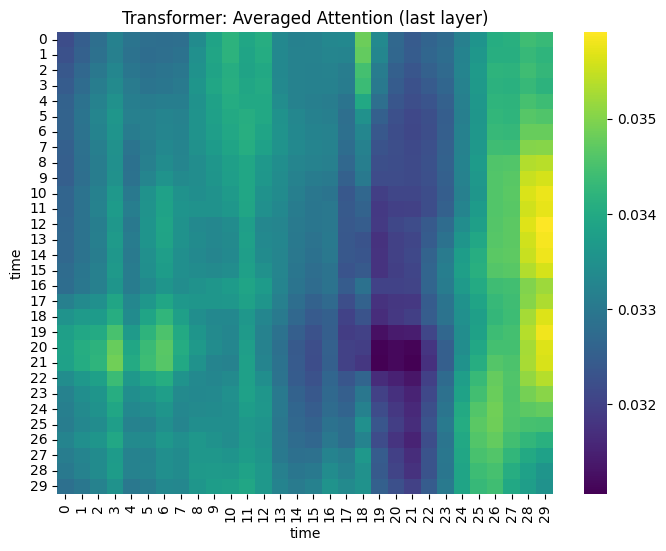

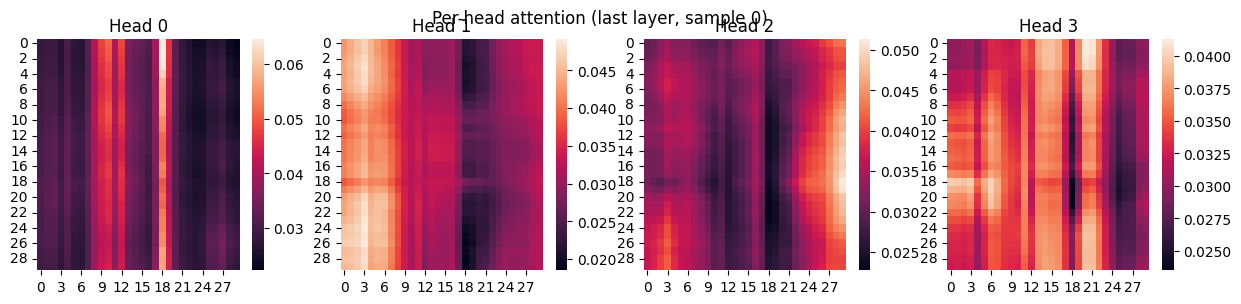

In [25]:
# Cell 14 — Transformer attention heatmap (取任一測試樣本)
# We'll forward one sample with return_attn=True and視覺化最後一層 head 的 attention (average over heads or show heads separately)
sample_X = torch.tensor(Xt[0:1], dtype=torch.float32).to(DEVICE)  # first test sample (B=1)
transformer_model.eval()
with torch.no_grad():
    out, attn_maps = transformer_model(sample_X, return_attn=True)
# attn_maps is list length num_layers; each attn_map shape (B, num_heads, T, T)
last_layer_attn = attn_maps[-1].squeeze(0).numpy()  # (num_heads, T, T)
# average across heads
avg_attn = last_layer_attn.mean(axis=0)  # (T, T)
plt.figure(figsize=(8,6))
sns.heatmap(avg_attn, cmap="viridis")
plt.title("Transformer: Averaged Attention (last layer)")
plt.xlabel("time")
plt.ylabel("time")
plt.show()

# Optionally display per-head heatmaps
num_heads = last_layer_attn.shape[0]
fig, axes = plt.subplots(1, min(num_heads,4), figsize=(15,3))
for i in range(min(num_heads,4)):
    sns.heatmap(last_layer_attn[i], ax=axes[i])
    axes[i].set_title(f"Head {i}")
plt.suptitle("Per-head attention (last layer, sample 0)")
plt.show()

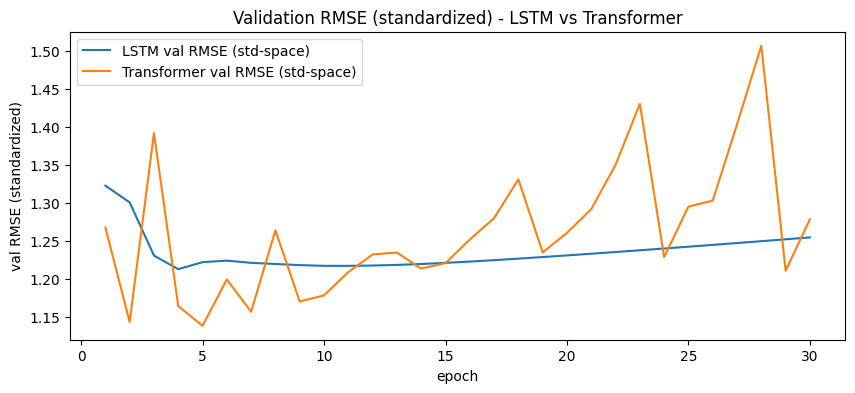

In [26]:
# Cell 15 — 驗證集學習曲線（epoch vs val RMSE）(LSTM & Transformer)
plt.figure(figsize=(10,4))
plt.plot(history_lstm["epoch"], history_lstm["val_rmse_s"], label="LSTM val RMSE (std-space)")
plt.plot(history_trans["epoch"], history_trans["val_rmse_s"], label="Transformer val RMSE (std-space)")
plt.xlabel("epoch"); plt.ylabel("val RMSE (standardized)"); plt.legend()
plt.title("Validation RMSE (standardized) - LSTM vs Transformer")
plt.show()

In [27]:
# Cell 16 — 技術指標比較（實驗設計建議與結果呈現）
# 這個 cell 提供 code 模板，讓你用不同指標集合跑 ablation：
# 範例：四類指標：趨勢型 (SMA_5,SMA_20), 震盪型 (RSI_14), 波動型 (MACD系列 or ATR), 量能型 (Volume)
# 我在此提供一個函式模板：給定 feature_subset names, 重新做 scaler / windows / train / eval，回傳 test RMSE
def run_experiment_with_features(feature_subset, model_type="lstm", epochs=20):
    # feature_subset: list of column names e.g. ["Open","High","Low","Close","Volume","SMA_5","SMA_20"]
    # --- build X matrices from df_t global variable
    # (For brevity, this function is a template; you can adapt and call it iteratively for each indicator group)
    pass

print("請用此模板對四類指標分別做實驗 (A: trend, B: oscillator, C: volatility, D: volume)，比較 RMSE/MAE。")

請用此模板對四類指標分別做實驗 (A: trend, B: oscillator, C: volatility, D: volume)，比較 RMSE/MAE。
